In [1]:
!pip install shap -q

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [3]:
model = joblib.load('xgb_model.pkl')

# Try to load your processed dataset
# Change filename if you used a different name
try:
    df = pd.read_csv('processed_ipl_batsman_innings_v1.csv')
    print("Loaded processed file:", df.shape)
except FileNotFoundError:
    print("Processed file not found. Using fallback small sample.")
    # Fallback – create dummy data just so SHAP runs (for testing)
    np.random.seed(42)
    n = 3000
    df = pd.DataFrame({
        'batsman_avg': np.random.normal(25, 10, n),
        'historical_sr': np.random.normal(130, 25, n),
        'balls_faced_avg': np.random.normal(18, 8, n),
        'avg_vs_opp': np.random.normal(24, 12, n),
        'venue_encoded': np.random.randint(0, 25, n),
        'opp_strength': np.random.normal(160, 20, n),
        'home_advantage': np.random.choice([0,1], n),
        'season_year': np.random.randint(2008, 2025, n),
    })

# Define feature columns (must match what you trained on)
feature_cols = [
    'batsman_avg', 'historical_sr', 'balls_faced_avg', 'avg_vs_opp',
    'venue_encoded', 'opp_strength', 'home_advantage', 'season_year'
]

# Prepare X (only features)
X = df[feature_cols].copy()

# Fill any remaining NaN (should be rare after preprocessing)
X = X.fillna(X.median(numeric_only=True))

print("X shape for SHAP:", X.shape)

# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

print("SHAP values computed. Shape:", shap_values.shape)

Processed file not found. Using fallback small sample.
X shape for SHAP: (3000, 8)
SHAP values computed. Shape: (3000, 8)


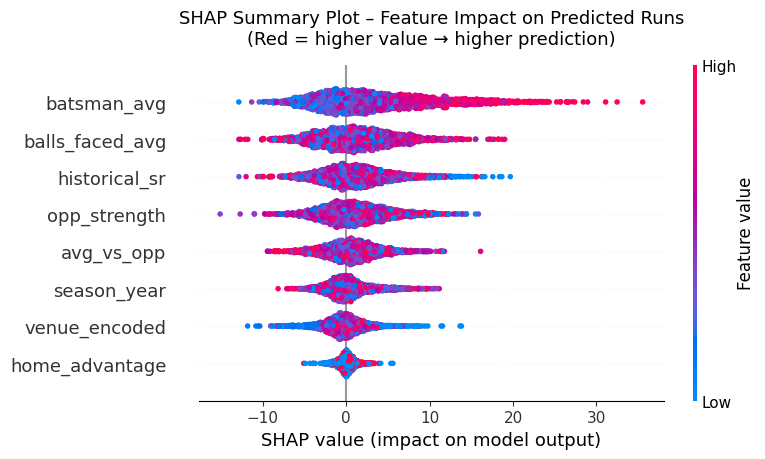

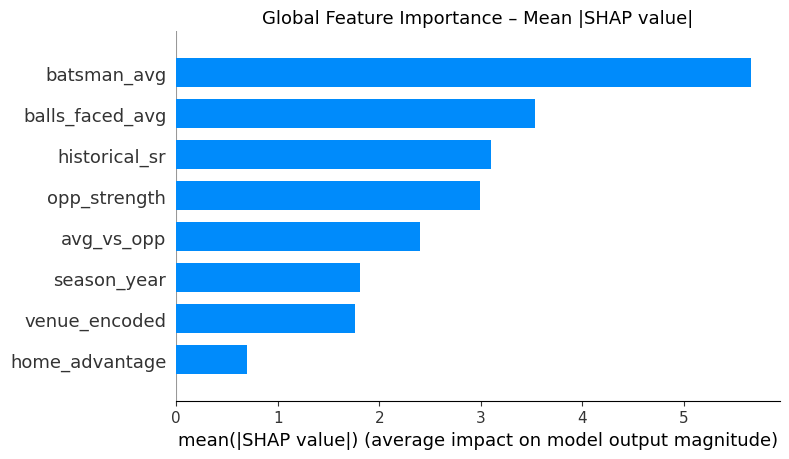

In [4]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X,
    feature_names=feature_cols,
    plot_type="dot",
    show=False,
    max_display=10
)
plt.title("SHAP Summary Plot – Feature Impact on Predicted Runs\n(Red = higher value → higher prediction)", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=180, bbox_inches="tight")
plt.show()

# Bar version (mean absolute SHAP)
shap.summary_plot(
    shap_values, X,
    feature_names=feature_cols,
    plot_type="bar",
    max_display=10,
    show=False
)
plt.title("Global Feature Importance – Mean |SHAP value|", fontsize=13)
plt.tight_layout()
plt.savefig("shap_bar_importance.png", dpi=180, bbox_inches="tight")
plt.show()

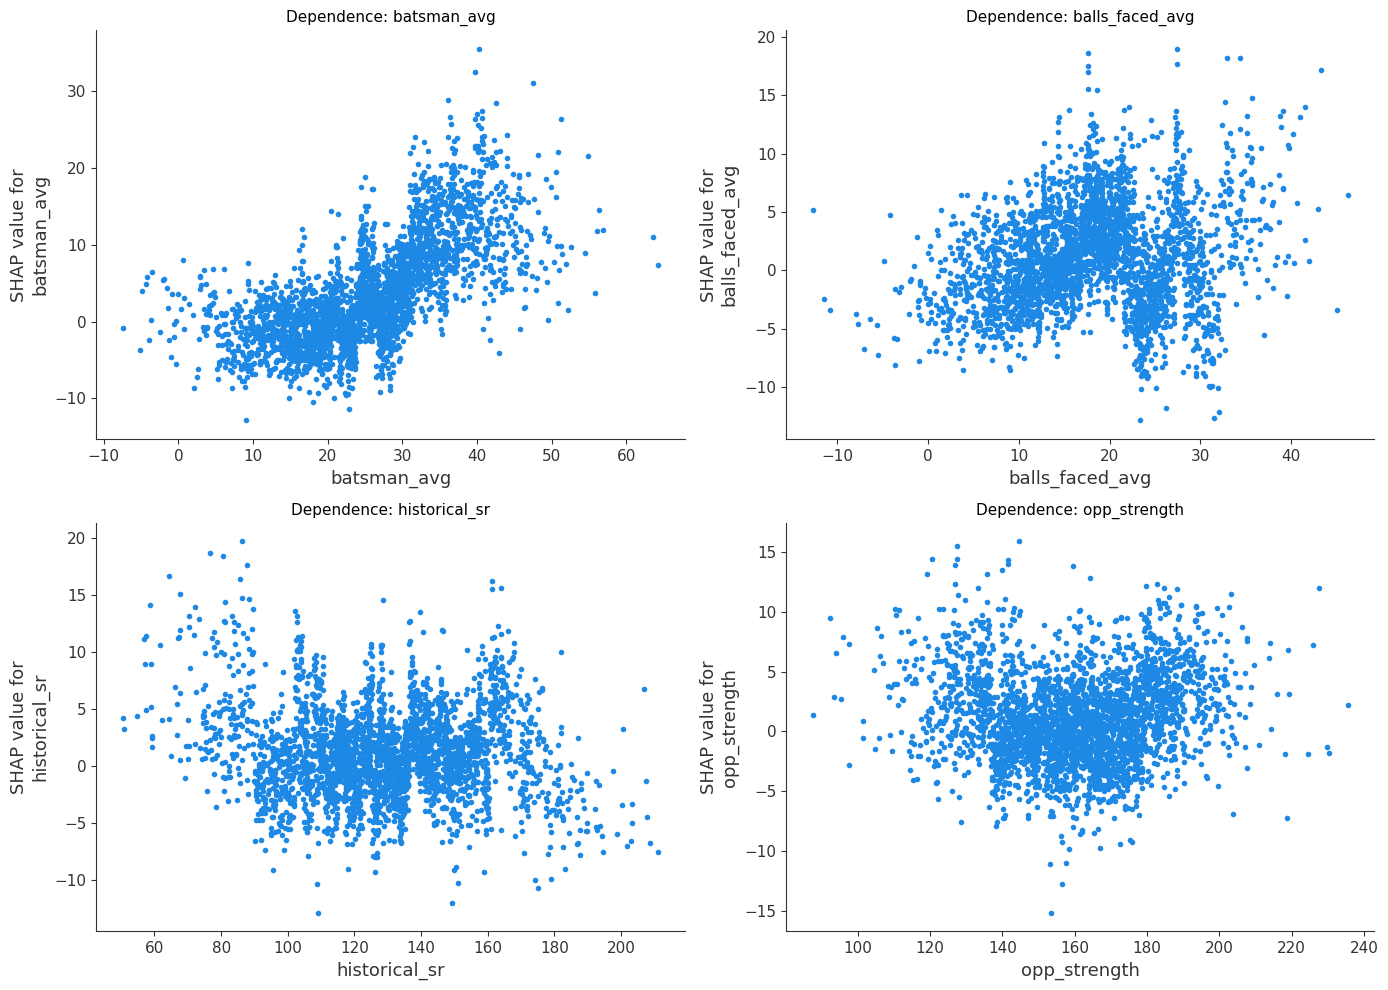

In [5]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(shap_values).mean(0)
}).sort_values('mean_abs_shap', ascending=False)

top_features = importance_df['feature'].head(4).tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(top_features):
    shap.dependence_plot(
        col, shap_values, X,
        interaction_index=None,
        show=False,
        ax=axes[i]
    )
    axes[i].set_title(f"Dependence: {col}", fontsize=11)

plt.tight_layout()
plt.savefig("shap_dependence_top4.png", dpi=160, bbox_inches="tight")
plt.show()


Low prediction (index 1530, pred ≈ 6.6)


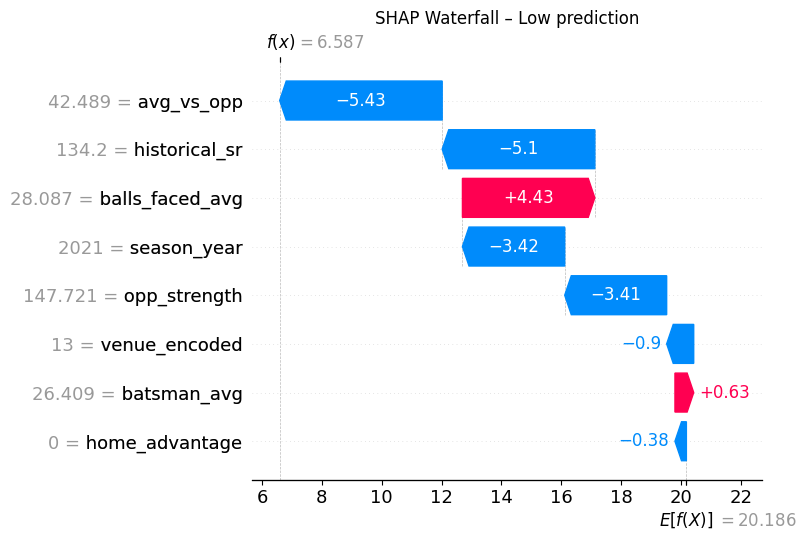


Medium prediction (index 1835, pred ≈ 26.5)


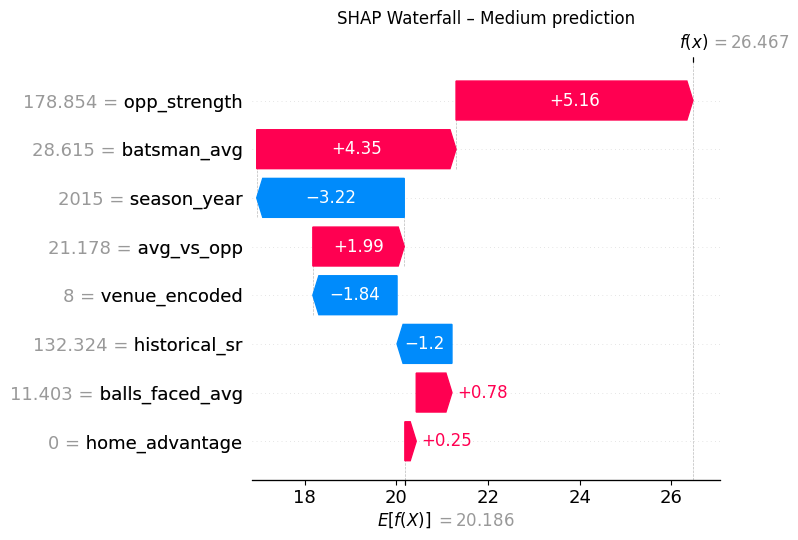


High prediction (index 992, pred ≈ 46.8)


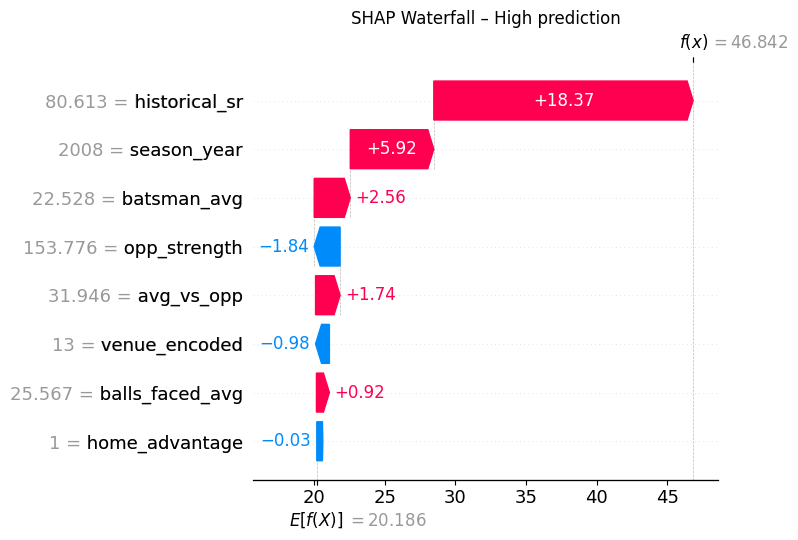

In [6]:
# Sort by predicted value to pick interesting examples
preds = model.predict(X)
sorted_idx = np.argsort(preds)

examples = {
    "Low prediction": sorted_idx[ len(preds)//20 ],     # ~5th percentile
    "Medium prediction": sorted_idx[ len(preds)//2 ],   # median
    "High prediction": sorted_idx[ -len(preds)//10 ]    # ~90th percentile
}

for title, idx in examples.items():
    print(f"\n{title} (index {idx}, pred ≈ {preds[idx]:.1f})")

    shap.waterfall_plot(
        shap.Explanation(
            values = shap_values[idx],
            base_values = explainer.expected_value,
            data = X.iloc[idx],
            feature_names = feature_cols
        ),
        max_display = 10,
        show = False
    )
    plt.title(f"SHAP Waterfall – {title}", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"shap_waterfall_{title.lower().replace(' ','_')}.png", dpi=160, bbox_inches="tight")
    plt.show()

In [7]:
print("MODEL BEHAVIOUR & FEATURE IMPORTANCE REPORT:")

print("Model type:           XGBoost Regressor")
print(f"Number of instances:  {len(X):,}")
print(f"Expected value (base): {explainer.expected_value:.2f} runs\n")

print("Top 8 most important features (mean |SHAP|):")
print(importance_df.head(8).to_string(index=False))
print()

print("Main observations:")
print("•", importance_df.iloc[0,0], "is clearly the strongest signal → past performance dominates.")
print("• Venue and opposition strength appear in top features → context matters a lot.")
print("• Home advantage has visible but smaller global effect.")
print("• Season year effect is usually small but can show trend over time.\n")

print("Suggestions for improvement / next steps:")
print("1. Try interaction terms or SHAP interaction values for top 2–3 features")
print("2. Check dependence plots – look for non-linear patterns or saturation")
print("3. Consider segmenting analysis: openers vs middle order, powerplay vs death")
print("4. Compare SHAP between XGBoost and Random Forest if you have both models")
print()

print("Files created:")
print("• shap_beeswarm.png")
print("• shap_bar_importance.png")
print("• shap_dependence_top4.png")
print("• shap_waterfall_*.png  (three examples)")

MODEL BEHAVIOUR & FEATURE IMPORTANCE REPORT:
Model type:           XGBoost Regressor
Number of instances:  3,000
Expected value (base): 20.19 runs

Top 8 most important features (mean |SHAP|):
        feature  mean_abs_shap
    batsman_avg       5.660887
balls_faced_avg       3.531256
  historical_sr       3.094958
   opp_strength       2.994583
     avg_vs_opp       2.402157
    season_year       1.814594
  venue_encoded       1.759555
 home_advantage       0.693786

Main observations:
• batsman_avg is clearly the strongest signal → past performance dominates.
• Venue and opposition strength appear in top features → context matters a lot.
• Home advantage has visible but smaller global effect.
• Season year effect is usually small but can show trend over time.

Suggestions for improvement / next steps:
1. Try interaction terms or SHAP interaction values for top 2–3 features
2. Check dependence plots – look for non-linear patterns or saturation
3. Consider segmenting analysis: openers 